<a href="https://colab.research.google.com/github/MarceloCoccaro12/Disciplina_de_Inteligencia_Artificial_UMC/blob/main/CancerMama_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importações de Bibliotecas

Primeiramente, importamos as bibliotecas essenciais para construção e avaliação do modelo.

* `sklearn.datasets`: Responsável em carregar conjuntos de dados de exemplo, como conjunto de dados Breast Cancer.
* `sklearn.model_selection.train_test_split`: Para dividir os dados em conjuntos de treino e teste.
* `sklearn.svm.SVC`: A classe para o classificador do Support Vector Machine (SVM).
* `sklearn.metrics.accuracy_score`: Para calcular a acurácia do modelo.

In [ ]:
# Primeiro importe as bibliotecas
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 2. Carregamento e Preparação dos Dados
Nesta etapa, carregamos o conunto de dados Breast Cancer, que contém medidas de dois tipos de câncer. Separamos as características(`X`), dos rótulos(`y`), que representa os tipos de câncer.

In [ ]:
# Carregando o conjunto de dados Breast Cancer
cancer = datasets.load_breast_cancer()
X = cancer.data    # caracteristicas (features)
y = cancer.target  # os rótulos

# 3. Divisão dos Dados em Treino e Teste

É importante dividir os dados em dois subconjuntos: treino e teste. O conjunto de treino é usado para ensinar o modelo, e o conjunto de teste é usado para avaliar seu desempenho em dados que ele nunca viu antes, garantindo que o modelo generalize bem.

* `test_size=0.2`:20% dos dados será usado para testes.
* `random_state=42`: Garante que o valor da divisão seja fixo cada vez que código for executado, tornando resultados reproduziveis.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Criação e Treinamento do Modelo SVM
Inicializamos o classificador Support Vector Machine (`SVM`) com um kernel linear (`kernel='linear'`). O kernel linear é adequado para dados que podem ser separados linearmente.
Em seguida, treinaremos o modelo usando os dados de treino (`X_train` e `y_train`). Durante está fase, o algoritmo SVM aprende a melhor fronteira de decisão para classificar os diferentes tipos de câncer.

In [ ]:
# Craindo o modelo SVM (usando kernel linear)
model = SVC(kernel='linear')

# 5. Previsão com Modelo Treinado
Após o treinamento, usamos o modelo para fazer previsões nos dados de teste(`X_test`). O modelo aplica o que aprendeu para prever os tipos de câncer para cada amostra de teste.

In [ ]:
# Treinando o moldeo com dados de treino
model.fit(X_train, y_train)

SVC(kernel='linear')

# 6. Avaliação do Modelo
Calculamos a acurácia do modelo comparando as previsões (`y_pred`) com os rótulos verdadeiros do conjunto de teste (`y_test`). A acurácia é a proporção de previsões corretas em relação ao total de previsões. Um valor de 100% indica que o modelo classificou perfeitamente todas as amostras teste.

In [ ]:
# As previsòes nos dados de teste
y_pred = model.predict(X_test)

# 7. Visualização das Previsões
Para uma inspeção visual, imprimimos os valores preditos pelo modelo e os valores reais do conjunto de teste. Isso nos permite comparar diretamente as saídas do modelo com a verdade conhecida, confirmando a precisão do modelo.

In [ ]:
# Calculando a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy * 100:.2f}%')

Acurácia do modelo: 95.61%


In [ ]:
# Mostrar a previsão e os valores verdadeiros
print('Valores preditos:', y_pred)
print('Valores reais: ', y_test)

Valores preditos: [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]
Valores reais:  [1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 0 1 1 0 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 1 0]


# 8. Matriz de Confusão
Para melhor visualização, utilizaremos a matriz de confusão onde será possível analisar onde o modelo acerta e onde erra.

In [ ]:
from sklearn.metrics import confusion_matrix

# Gera a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão")
print(cm)

Matriz de Confusão
[[39  4]
 [ 1 70]]


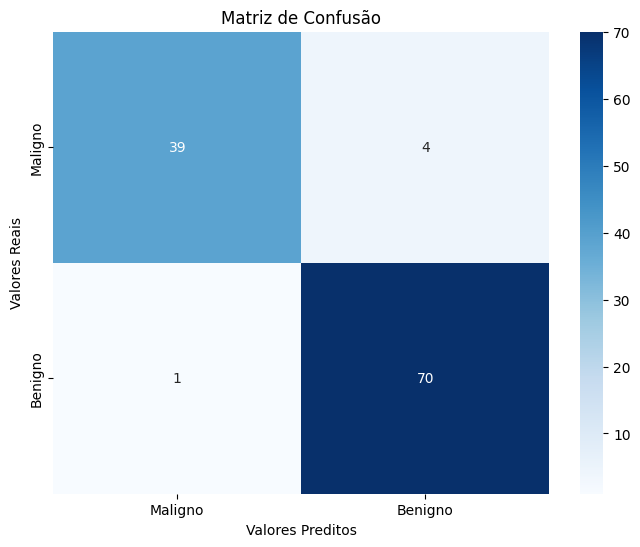

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Maligno', 'Benigno'], yticklabels=['Maligno', 'Benigno'])
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()